## Hierarchial Clustering

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram 
import pandas as pd
import numpy as np 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 

KeyboardInterrupt: 

In [4]:
df_pca = pd.read_csv('pca_data.csv') 

In [29]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,loan_status
0,-1.728215,-1.258091,-0.312773,-0.045634,0.854351,0.537882,-0.869909,0.584497,-0.568703,0.482179,0.011130,0.133843,-0.103153,0
1,-1.567827,2.312637,-1.945223,-0.710226,0.089168,-0.678636,0.463014,-1.144369,-1.436038,1.497182,0.348721,0.413940,0.221846,1
2,-0.779396,5.424083,0.505062,-0.232916,-0.219352,-0.310517,0.531038,-0.163211,0.915722,0.360974,-0.168894,0.593612,-0.035629,1
3,-0.150134,5.477579,0.515937,-0.645080,0.650338,-0.646083,0.721074,-0.136536,0.903001,0.327798,-0.183010,0.632383,-0.196327,1
4,-1.975492,-0.558320,-0.634289,-1.346783,-0.149976,-0.548071,-0.490574,-0.727704,-0.932912,-0.032601,-0.461750,-0.183052,-0.139825,1


In [5]:
x_cluster = df_pca.drop('loan_status', axis= 1) 

In [6]:
range_n_clusters = range(2, 10)     # Try cluster numbers from 2 to 9

### Single Linkage

In [ ]:
single_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='single' 
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    single_link_scores.append(score)

print("Single scores:", single_link_scores)

Single scores: [0.8928457043198474, 0.8373871578235533, 0.8373453810406468, 0.8373298586543383, 0.7876627992467808, 0.7175075924760271, 0.7174845569796108, 0.717479726168088]


### Ward Linkage

In [ ]:
ward_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    ward_link_scores.append(score)

print("Ward scores:", ward_link_scores)

Ward scores: [0.22871632208507714, 0.13899023956559356, 0.15439842418707983, 0.1199360367220532, 0.13174769633758013, 0.13366430781460426, 0.10013182947666015, 0.09191620388255109]


### Complete Linkage

In [ ]:
complete_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='complete'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    complete_link_scores.append(score)

print("Complete scores:", complete_link_scores)

Complete scores: [0.8639682172403431, 0.5985459786857066, 0.5984114601453645, 0.5429784615362123, 0.48917243039255354, 0.1715680391097791, 0.15523939417727162, 0.15459269392750954]


### Average Linkage

In [ ]:
average_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='average'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    average_link_scores.append(score)

print("Average scores:", average_link_scores)

Average scores: [0.8639682172403431, 0.8373871578235533, 0.6866743821546696, 0.49059319203536905, 0.4891668368968519, 0.4891268488452628, 0.4760181244359938, 0.4759887084857108]


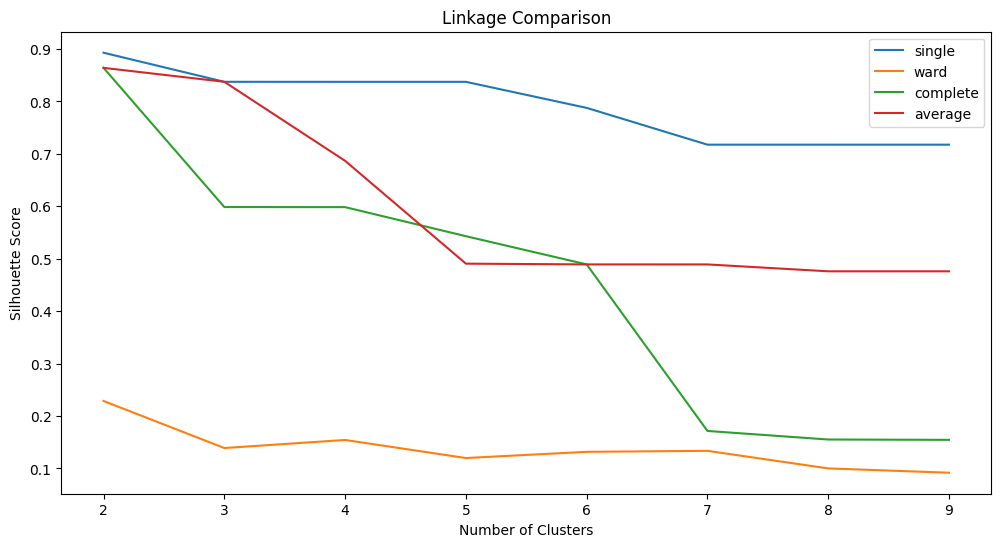

In [ ]:


plt.figure(figsize= (12, 6))
plt.plot(range_n_clusters, single_link_scores, label='single')
plt.plot(range_n_clusters, ward_link_scores, label='ward')
plt.plot(range_n_clusters, complete_link_scores, label='complete')
plt.plot(range_n_clusters, average_link_scores, label='average')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Linkage Comparison")
plt.legend()
plt.show()

In [ ]:
def best_k(scores, k_range):
    best_k = k_range[np.argmax(scores)]
    best_score = max(scores)
    return best_k, best_score

In [ ]:
print("Single:", best_k(single_link_scores, range_n_clusters))
print("Ward:", best_k(ward_link_scores, range_n_clusters))
print("Complete:", best_k(complete_link_scores, range_n_clusters))
print("Average:", best_k(average_link_scores, range_n_clusters))

Single: (2, 0.8928457043198474)
Ward: (2, 0.22871632208507714)
Complete: (2, 0.8639682172403431)
Average: (2, 0.8639682172403431)


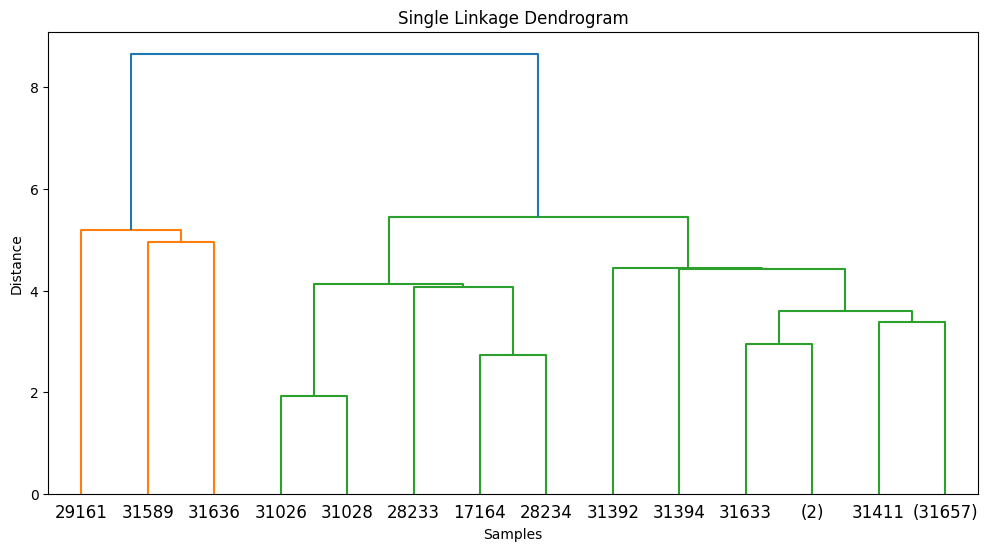

In [ ]:
Z_single = linkage(x_cluster, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z_single, truncate_mode='level', p=5)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

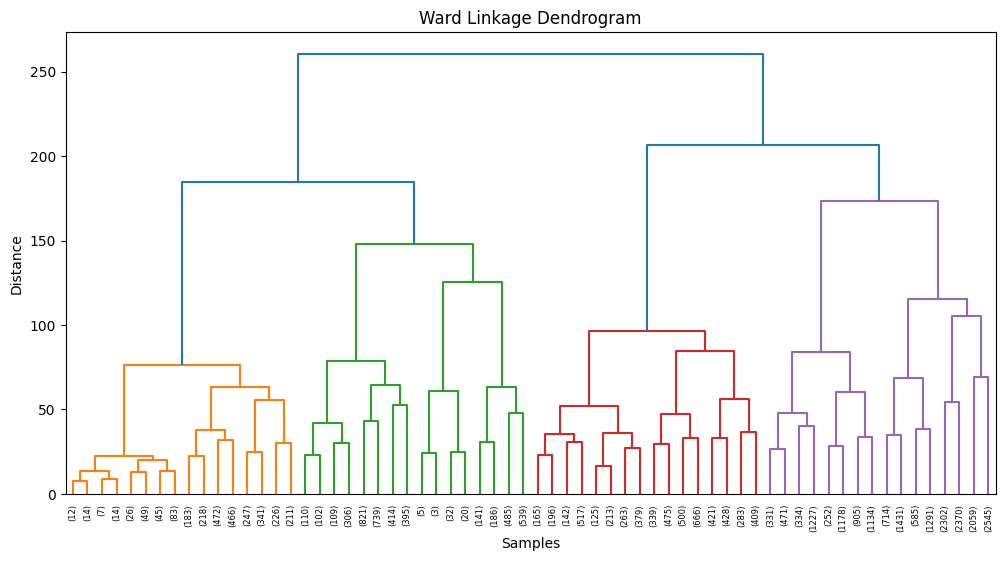

In [ ]:
Z_ward = linkage(x_cluster, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title("Ward Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

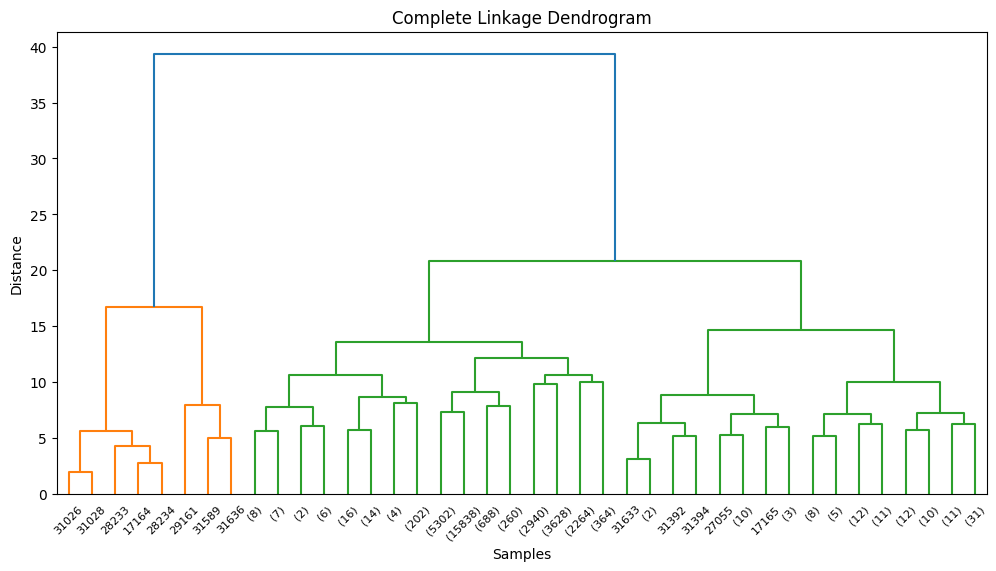

In [ ]:
Z_complete = linkage(x_cluster, method='complete')

plt.figure(figsize=(12, 6))
dendrogram(Z_complete, truncate_mode='level', p=5)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

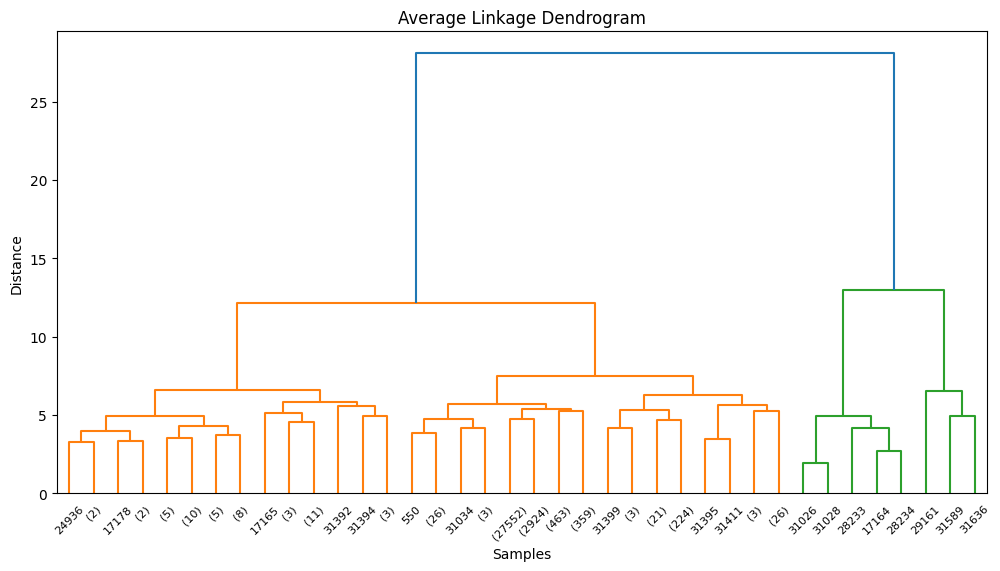

In [ ]:
Z_average = linkage(x_cluster, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z_average, truncate_mode='level', p=5)
plt.title("Average Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Final Model

In [ ]:
final_model2 = AgglomerativeClustering(n_clusters= 3, linkage= 'ward', metric= 'euclidean') 

clusters2 = final_model2.fit_predict(x_cluster)

NameError: name 'AgglomerativeClustering' is not defined

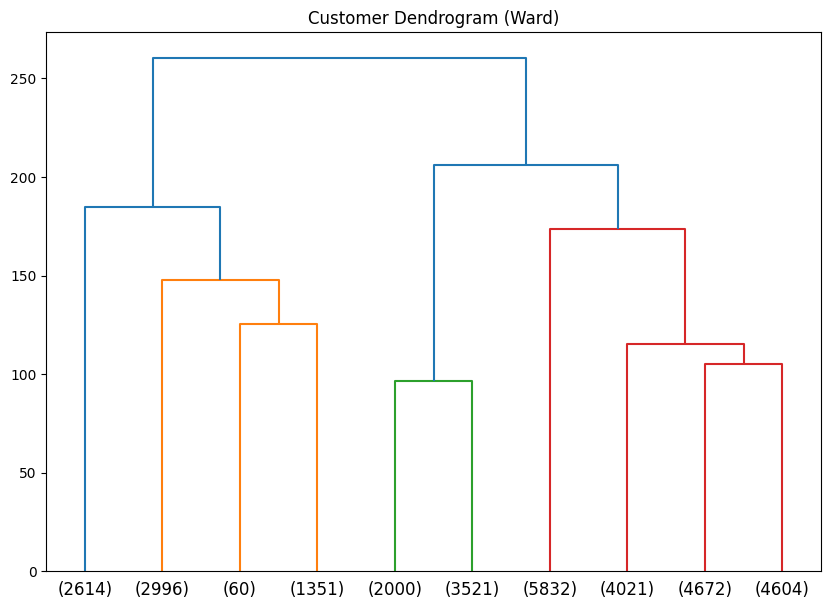

In [ ]:
import scipy.cluster.hierarchy as shc


plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (Ward)")
# Use a sample so the plot is readable
dend = shc.dendrogram(shc.linkage(x_cluster, method='ward'),truncate_mode="lastp",p=10)
plt.show()

In [19]:
data_with_clusters2 = pd.read_csv('cleaned_data.csv') 

In [20]:
data_with_clusters2['ward_cluster'] = clusters2

In [21]:
data_with_clusters2.head(30) 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,True,False,False,False,False,False,False,1
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,False,True,False,False,False,False,False,2
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,False,True,False,False,False,False,False,2
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,False,True,False,False,False,False,True,2
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,True,False,False,False,False,False,False,False,1
5,26,77100,8.0,35000,0.1242,1,0.45,3,False,False,...,False,False,True,False,False,False,False,False,False,2
6,24,78956,5.0,35000,0.1111,1,0.44,4,False,False,...,False,False,True,False,False,False,False,False,False,2
7,24,83000,8.0,35000,0.0890,1,0.42,2,False,False,...,True,False,False,False,False,False,False,False,False,2
8,22,85000,6.0,35000,0.1037,1,0.41,4,False,False,...,False,True,True,False,False,False,False,False,False,2
9,21,10000,2.0,4500,0.0863,1,0.45,2,False,True,...,False,False,False,False,False,False,False,False,False,2


In [22]:
data_with_clusters2.tail(20)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
31651,54,129000,6.0,9000,0.114900,1,0.07,24,False,False,...,False,False,True,False,False,False,False,False,False,0
31652,61,160000,30.0,24000,0.103800,0,0.15,21,False,False,...,True,False,True,False,False,False,False,False,False,0
31653,52,71520,0.0,7000,0.168200,1,0.10,24,False,False,...,False,False,False,False,False,True,False,False,True,0
31654,53,45000,0.0,5600,0.137900,0,0.12,28,False,False,...,True,False,False,True,False,False,False,False,False,0
31655,57,40000,1.0,15000,0.089000,1,0.38,21,False,False,...,False,False,False,False,False,False,False,False,False,0
31656,52,30000,6.0,5000,0.127300,0,0.17,18,False,False,...,False,True,False,True,False,False,False,False,False,0
31657,53,85000,2.0,8000,0.077400,0,0.09,26,False,False,...,True,False,False,False,False,False,False,False,False,0
31658,60,49008,5.0,12000,0.137900,0,0.24,21,False,True,...,True,False,False,True,False,False,False,False,True,0
31659,51,60000,1.0,7500,0.073284,0,0.13,23,False,False,...,True,False,False,False,False,False,False,False,False,0
31660,58,72000,5.0,4500,0.109958,0,0.06,23,False,False,...,False,False,True,False,False,False,False,False,False,0


In [37]:
data_with_clusters2['ward_cluster'].value_counts()

ward_cluster
1    19129
0     7021
2     5521
Name: count, dtype: int64

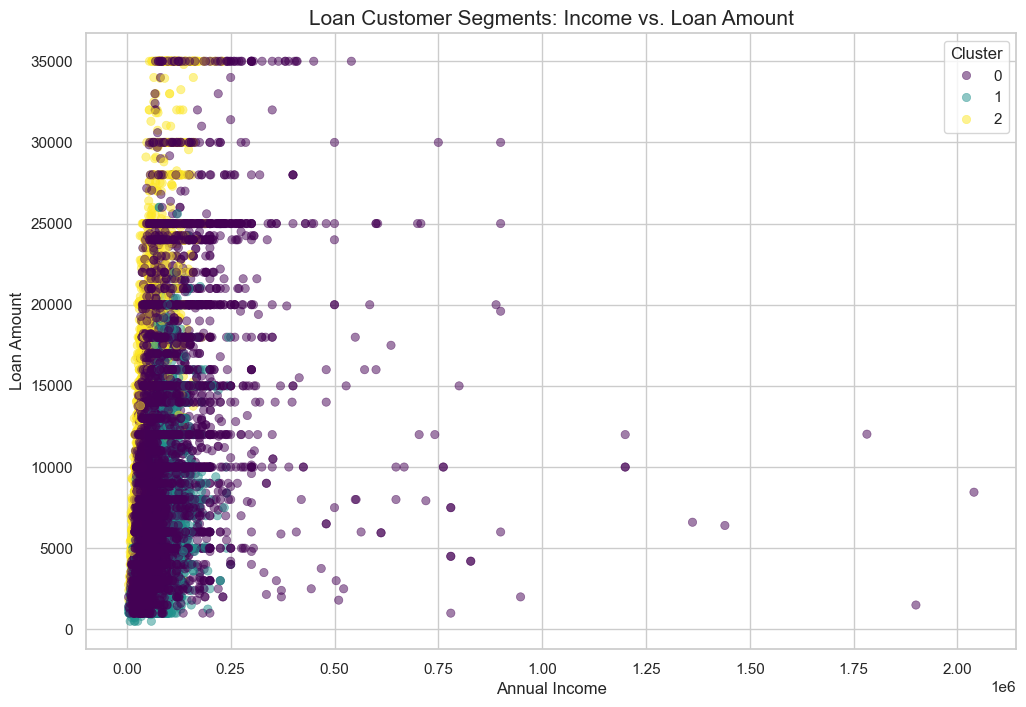

In [34]:
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Using the original feature names for the axes
# I've added a log scale for income in case you have high-earners that squash the plot
plot = sns.scatterplot(
    data=data_with_clusters2, 
    x='person_income', 
    y='loan_amnt', 
    hue='ward_cluster', 
    palette='viridis', 
    alpha=0.5,
    edgecolor=None
)

plt.title('Loan Customer Segments: Income vs. Loan Amount', fontsize=15)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Cluster')

# Optional: If your income data has extreme outliers, uncomment the line below:
# plt.xscale('log') 

plt.show()

In [35]:
# This gives you the average 'vibe' of each cluster
profile = data_with_clusters2.groupby('ward_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].mean()
print(profile)

              person_age  person_income     loan_amnt  loan_int_rate
ward_cluster                                                        
0              34.986469   95157.744196  11229.255092       0.108278
1              25.817973   57823.273564   7139.259763       0.107168
2              25.483789   56396.786452  15906.692628       0.123153


## Customer Persona Analysis

After applying **Ward Linkage Hierarchical Clustering**, we identified three distinct customer segments. Below is the profile for each group:

---

### Cluster 0: "The Established Professionals"
* **Average Age:** ~35 years (Significantly older demographic).
* **Average Income:** ~$95,000 (Primary high-earner group).
* **Loan Behavior:** Moderate loan amounts ($\approx$11k) with the **lowest interest rates** (10.8%).
> **Business Insight:** These are likely the most stable, lower-risk clients. They represent a "Premium" segment for long-term financial products.

---

### Cluster 1: "The Conservative Starters"
* **Average Age:** ~26 years (Early-career demographic).
* **Average Income:** ~$58,000 (Modest earnings).
* **Loan Behavior:** Highly cautious; they take out the **smallest loans** ($\approx$7k) with stable interest rates.
> **Business Insight:** This is an "entry-level" segment. These are young individuals borrowing manageable amounts, representing a growth opportunity as their careers progress.

---

### Cluster 2: "The High-Leverage Youth"
* **Average Age:** ~25 years (The youngest demographic).
* **Average Income:** ~$56,000 (Similar to Cluster 1).
* **Loan Behavior:** High-risk outliers; they take out the **highest loans** ($\approx$16k) despite lower income, resulting in the **highest interest rates** (12.3%).
> **Business Insight:** This is the "High Risk" segment. Their high debt-to-income ratio makes them candidates for closer monitoring or specialized risk-mitigation strategies.

In [36]:
cluster_map = {
    0: 'Established Professionals',
    1: 'Conservative Starters',
    2: 'High-Leverage Borrowers'
}

data_with_clusters2['cluster_name'] = data_with_clusters2['ward_cluster'].map(cluster_map)

# Now your counts are readable!
print(data_with_clusters2['cluster_name'].value_counts())

cluster_name
Conservative Starters        19129
Established Professionals     7021
High-Leverage Borrowers       5521
Name: count, dtype: int64


## Final Analysis 

| Feature | Using 0, 1, 2 | Using Names |
| :--- | :--- | :--- |
| **Communication** | "Cluster 2 has high interest rates." | "High-Leverage Borrowers are charged more due to risk." |
| **Actionability** | "Target Cluster 0." | "Offer premium financial products to the Established group." |
| **Professionalism** | Looks like a technical exercise. | Looks like a professional customer segmentation analysis. |

In [38]:
data_with_clusters2.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster,cluster_name
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,True,False,False,False,False,False,False,1,Conservative Starters
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,True,False,False,False,False,False,2,High-Leverage Borrowers
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,True,False,False,False,False,False,2,High-Leverage Borrowers
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,True,False,False,False,False,True,2,High-Leverage Borrowers
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,True,False,False,False,False,False,False,False,1,Conservative Starters
